# Lab 6 — Graph Neural Networks

This notebook solves the explicit homework exercises from **Tutorial 2: Node Classification with Graph Neural Networks** from the PyTorch Geometric official tutorial list.

The lab brief asks to follow the first three PyG tutorials and solve the exercises from tutorial 2. The code below focuses on the tutorial 2 exercises, because those are the exercises that require submitted solutions.


## What is solved

The notebook includes:

1. Dataset loading and inspection for Cora.
2. MLP baseline that ignores graph edges.
3. Fixed-epoch 2-layer GCN baseline.
4. **Exercise 1:** validation-based model selection using `data.val_mask`.
5. **Exercise 2:** variable-depth `DeepGCN`, experiments for `num_layers = [1, 2, 4, 6, 8, 10]`, and a validation-accuracy plot.
6. **Exercise 3:** 2-layer `GATConv` model with 8 attention heads, dropout 0.6, ELU activation, validation selection, and comparison to MLP/GCN.


## Setup

Run this first. In Google Colab, the cell installs PyTorch Geometric if needed.


In [1]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("torch_geometric") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"])


In [2]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.nn import Linear
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, GATConv

SEED = 1234567

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Load the Cora dataset

Cora is a citation network. Nodes are papers, edges are citation links, node features are bag-of-words vectors, and the task is to classify each paper.


In [3]:
dataset = Planetoid(root="data/Planetoid", name="Cora", transform=NormalizeFeatures())
data = dataset[0].to(device)

print(dataset)
print("Number of graphs:", len(dataset))
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print("Number of node features:", dataset.num_features)
print("Number of classes:", dataset.num_classes)
print("Training nodes:", int(data.train_mask.sum()))
print("Validation nodes:", int(data.val_mask.sum()))
print("Test nodes:", int(data.test_mask.sum()))


Processing...


Cora()
Number of graphs: 1
Number of nodes: 2708
Number of edges: 10556
Number of node features: 1433
Number of classes: 7
Training nodes: 140
Validation nodes: 500
Test nodes: 1000


Done!


## Shared training and evaluation helpers


In [4]:
def train_one_epoch(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return float(loss.item())

@torch.no_grad()
def accuracy(model, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum().item()
    return correct / int(mask.sum())

def train_fixed_epochs(model, lr=0.01, weight_decay=5e-4, epochs=200, print_every=20):
    """Train for a fixed number of epochs and report final train/val/test accuracy."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(1, epochs + 1):
        loss = train_one_epoch(model, optimizer, criterion)
        train_acc = accuracy(model, data.train_mask)
        val_acc = accuracy(model, data.val_mask)
        test_acc = accuracy(model, data.test_mask)
        history.append({
            "epoch": epoch,
            "loss": loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "test_acc": test_acc,
        })

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(
                f"Epoch {epoch:03d} | "
                f"Loss {loss:.4f} | "
                f"Train {train_acc:.4f} | "
                f"Val {val_acc:.4f} | "
                f"Test {test_acc:.4f}"
            )

    final_summary = {
        "final_train_acc": history[-1]["train_acc"],
        "final_val_acc": history[-1]["val_acc"],
        "final_test_acc": history[-1]["test_acc"],
    }
    return model, pd.DataFrame(history), final_summary

def train_with_validation_selection(model, lr=0.01, weight_decay=5e-4, epochs=200, print_every=20):
    """Train and restore the model state with the best validation accuracy."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    best_test_acc = -1.0
    best_epoch = 0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        loss = train_one_epoch(model, optimizer, criterion)
        train_acc = accuracy(model, data.train_mask)
        val_acc = accuracy(model, data.val_mask)
        test_acc = accuracy(model, data.test_mask)

        history.append({
            "epoch": epoch,
            "loss": loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "test_acc": test_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(
                f"Epoch {epoch:03d} | "
                f"Loss {loss:.4f} | "
                f"Train {train_acc:.4f} | "
                f"Val {val_acc:.4f} | "
                f"Test {test_acc:.4f}"
            )

    model.load_state_dict(best_state)
    summary = {
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "test_acc_at_best_val": best_test_acc,
    }
    return model, pd.DataFrame(history), summary


## Baseline 1 — MLP without graph structure

This baseline ignores `edge_index`, so it only uses each node's feature vector.


In [5]:
class MLP(nn.Module):
    def __init__(self, hidden_channels=16):
        super().__init__()
        self.lin1 = Linear(dataset.num_features, hidden_channels)
        self.lin2 = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index=None):
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x

set_seed()
mlp_model, mlp_history, mlp_summary = train_fixed_epochs(
    MLP(hidden_channels=16),
    lr=0.01,
    weight_decay=5e-4,
    epochs=200,
    print_every=20,
)

print("MLP final test accuracy:", f'{mlp_summary["final_test_acc"]:.4f}')


Epoch 001 | Loss 1.9501 | Train 0.1429 | Val 0.0720 | Test 0.0910
Epoch 020 | Loss 1.7451 | Train 0.9786 | Val 0.3580 | Test 0.3670
Epoch 040 | Loss 1.3537 | Train 1.0000 | Val 0.5300 | Test 0.5450
Epoch 060 | Loss 0.8985 | Train 1.0000 | Val 0.5840 | Test 0.5740
Epoch 080 | Loss 0.6441 | Train 1.0000 | Val 0.5740 | Test 0.5690
Epoch 100 | Loss 0.5516 | Train 1.0000 | Val 0.5820 | Test 0.5740
Epoch 120 | Loss 0.5118 | Train 1.0000 | Val 0.5780 | Test 0.5730
Epoch 140 | Loss 0.5176 | Train 1.0000 | Val 0.5600 | Test 0.5700
Epoch 160 | Loss 0.4457 | Train 1.0000 | Val 0.5600 | Test 0.5730
Epoch 180 | Loss 0.3938 | Train 1.0000 | Val 0.5640 | Test 0.5820
Epoch 200 | Loss 0.3189 | Train 1.0000 | Val 0.5660 | Test 0.5870
MLP final test accuracy: 0.5870


## Baseline 2 — fixed-epoch 2-layer GCN

This is the basic GCN model from the tutorial before validation-based model selection.


In [6]:
class GCN(nn.Module):
    def __init__(self, hidden_channels=16):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

set_seed()
gcn_fixed_model, gcn_fixed_history, gcn_fixed_summary = train_fixed_epochs(
    GCN(hidden_channels=16),
    lr=0.01,
    weight_decay=5e-4,
    epochs=200,
    print_every=20,
)

print("GCN fixed-epoch final test accuracy:", f'{gcn_fixed_summary["final_test_acc"]:.4f}')


Epoch 001 | Loss 1.9465 | Train 0.2286 | Val 0.1660 | Test 0.1630
Epoch 020 | Loss 1.7568 | Train 0.8786 | Val 0.6180 | Test 0.6500
Epoch 040 | Loss 1.3972 | Train 0.9714 | Val 0.7360 | Test 0.7410
Epoch 060 | Loss 1.0201 | Train 0.9714 | Val 0.7540 | Test 0.7890
Epoch 080 | Loss 0.8277 | Train 0.9714 | Val 0.7740 | Test 0.8020
Epoch 100 | Loss 0.6375 | Train 0.9857 | Val 0.7840 | Test 0.8110
Epoch 120 | Loss 0.5309 | Train 0.9857 | Val 0.7740 | Test 0.8080
Epoch 140 | Loss 0.4919 | Train 0.9857 | Val 0.7920 | Test 0.8180
Epoch 160 | Loss 0.4715 | Train 0.9929 | Val 0.7820 | Test 0.8140
Epoch 180 | Loss 0.3631 | Train 0.9857 | Val 0.7960 | Test 0.8230
Epoch 200 | Loss 0.3751 | Train 1.0000 | Val 0.7880 | Test 0.8140
GCN fixed-epoch final test accuracy: 0.8140


## Exercise 1 — validation-based model selection

Instead of reporting the model after the final epoch, keep the weights from the epoch with the highest validation accuracy. Then report test accuracy after restoring those weights.


In [7]:
set_seed()
gcn_val_model, gcn_val_history, gcn_val_summary = train_with_validation_selection(
    GCN(hidden_channels=16),
    lr=0.01,
    weight_decay=5e-4,
    epochs=300,
    print_every=20,
)

print("Best GCN epoch:", gcn_val_summary["best_epoch"])
print("Best validation accuracy:", f'{gcn_val_summary["best_val_acc"]:.4f}')
print("Test accuracy at best validation epoch:", f'{gcn_val_summary["test_acc_at_best_val"]:.4f}')


Epoch 001 | Loss 1.9465 | Train 0.2286 | Val 0.1660 | Test 0.1630
Epoch 020 | Loss 1.7568 | Train 0.8786 | Val 0.6180 | Test 0.6500
Epoch 040 | Loss 1.3972 | Train 0.9714 | Val 0.7360 | Test 0.7410
Epoch 060 | Loss 1.0201 | Train 0.9714 | Val 0.7540 | Test 0.7890
Epoch 080 | Loss 0.8277 | Train 0.9714 | Val 0.7740 | Test 0.8020
Epoch 100 | Loss 0.6375 | Train 0.9857 | Val 0.7840 | Test 0.8110
Epoch 120 | Loss 0.5309 | Train 0.9857 | Val 0.7740 | Test 0.8080
Epoch 140 | Loss 0.4919 | Train 0.9857 | Val 0.7920 | Test 0.8180
Epoch 160 | Loss 0.4715 | Train 0.9929 | Val 0.7820 | Test 0.8140
Epoch 180 | Loss 0.3631 | Train 0.9857 | Val 0.7960 | Test 0.8230
Epoch 200 | Loss 0.3751 | Train 1.0000 | Val 0.7880 | Test 0.8140
Epoch 220 | Loss 0.3122 | Train 0.9929 | Val 0.7820 | Test 0.8080
Epoch 240 | Loss 0.2729 | Train 0.9929 | Val 0.7900 | Test 0.8160
Epoch 260 | Loss 0.3289 | Train 1.0000 | Val 0.7860 | Test 0.8130
Epoch 280 | Loss 0.2833 | Train 1.0000 | Val 0.7860 | Test 0.8130
Epoch 300 

## Exercise 2 — over-smoothing vs. depth

Complete a `DeepGCN` class that supports a variable number of GCN layers. The required layer counts are `[1, 2, 4, 6, 8, 10]`.

Important detail: `num_layers == 1` must be handled specially, because there is no hidden layer in that case.


In [8]:
class DeepGCN(nn.Module):
    def __init__(self, hidden_channels=16, num_layers=2, dropout=0.5):
        super().__init__()
        if num_layers < 1:
            raise ValueError("num_layers must be at least 1")

        self.dropout = dropout
        self.convs = nn.ModuleList()

        if num_layers == 1:
            # Direct input -> class output layer.
            self.convs.append(GCNConv(dataset.num_features, dataset.num_classes))
        else:
            # First layer: input -> hidden.
            self.convs.append(GCNConv(dataset.num_features, hidden_channels))

            # Middle hidden -> hidden layers.
            for _ in range(num_layers - 2):
                self.convs.append(GCNConv(hidden_channels, hidden_channels))

            # Final layer: hidden -> classes.
            self.convs.append(GCNConv(hidden_channels, dataset.num_classes))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x


In [9]:
def run_depth_experiment(num_layers, hidden_channels=16, epochs=200):
    set_seed()
    model = DeepGCN(hidden_channels=hidden_channels, num_layers=num_layers, dropout=0.5)
    _, _, summary = train_with_validation_selection(
        model,
        lr=0.01,
        weight_decay=5e-4,
        epochs=epochs,
        print_every=0,
    )
    return summary["best_val_acc"], summary["test_acc_at_best_val"], summary["best_epoch"]

layer_counts = [1, 2, 4, 6, 8, 10]
depth_rows = []

for num_layers in layer_counts:
    print(f"Running DeepGCN with {num_layers} layer(s)")
    best_val, test_at_best, best_epoch = run_depth_experiment(num_layers=num_layers)
    depth_rows.append({
        "num_layers": num_layers,
        "hidden_channels": 16,
        "best_epoch": best_epoch,
        "best_val_acc": best_val,
        "test_acc_at_best_val": test_at_best,
    })

depth_results = pd.DataFrame(depth_rows)
display(depth_results)


Running DeepGCN with 1 layer(s)
Running DeepGCN with 2 layer(s)
Running DeepGCN with 4 layer(s)
Running DeepGCN with 6 layer(s)
Running DeepGCN with 8 layer(s)
Running DeepGCN with 10 layer(s)


,num_layers,hidden_channels,best_epoch,best_val_acc,test_acc_at_best_val
0,1,16,20,0.750,0.750
1,2,16,172,0.798,0.815
2,4,16,154,0.758,0.733
3,6,16,83,0.422,0.429
4,8,16,181,0.552,0.528
5,10,16,1,0.316,0.319


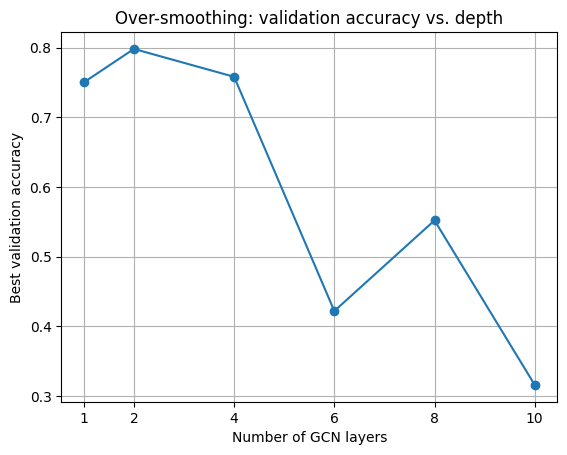

In [10]:
plt.figure()
plt.plot(depth_results["num_layers"], depth_results["best_val_acc"], marker="o")
plt.xlabel("Number of GCN layers")
plt.ylabel("Best validation accuracy")
plt.title("Over-smoothing: validation accuracy vs. depth")
plt.xticks(layer_counts)
plt.grid(True)
plt.show()


### Optional extra: hidden dimensionality

The exact exercise is about depth, but this extra comparison also checks the effect of hidden size for a 2-layer GCN.


In [11]:
hidden_rows = []

for hidden_channels in [8, 16, 32, 64]:
    print(f"Running 2-layer GCN with hidden_channels={hidden_channels}")
    set_seed()
    _, _, summary = train_with_validation_selection(
        DeepGCN(hidden_channels=hidden_channels, num_layers=2, dropout=0.5),
        lr=0.01,
        weight_decay=5e-4,
        epochs=200,
        print_every=0,
    )
    hidden_rows.append({
        "hidden_channels": hidden_channels,
        "num_layers": 2,
        **summary,
    })

hidden_results = pd.DataFrame(hidden_rows)
display(hidden_results)


Running 2-layer GCN with hidden_channels=8
Running 2-layer GCN with hidden_channels=16
Running 2-layer GCN with hidden_channels=32
Running 2-layer GCN with hidden_channels=64


,hidden_channels,num_layers,best_epoch,best_val_acc,test_acc_at_best_val
0,8,2,153,0.792,0.804
1,16,2,172,0.798,0.815
2,32,2,86,0.800,0.816
3,64,2,49,0.804,0.820


## Exercise 3 — replace `GCNConv` with `GATConv`

Architecture required:

- Layer 1: `GATConv(in_channels, 8, heads=8, dropout=0.6)` so the output has dimension `8 * 8 = 64`.
- Layer 2: `GATConv(64, num_classes, heads=1, concat=False, dropout=0.6)`.
- Use `F.elu` after the first GAT layer.
- Apply dropout with `p=0.6` before each GAT layer.


In [12]:
class GAT(nn.Module):
    def __init__(self, hidden_channels=8, heads=8, dropout=0.6):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATConv(
            dataset.num_features,
            hidden_channels,
            heads=heads,
            dropout=dropout,
        )
        self.conv2 = GATConv(
            hidden_channels * heads,
            dataset.num_classes,
            heads=1,
            concat=False,
            dropout=dropout,
        )

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

set_seed()
gat_model, gat_history, gat_summary = train_with_validation_selection(
    GAT(hidden_channels=8, heads=8, dropout=0.6),
    lr=0.005,
    weight_decay=5e-4,
    epochs=200,
    print_every=20,
)

print("Best GAT epoch:", gat_summary["best_epoch"])
print("Best validation accuracy:", f'{gat_summary["best_val_acc"]:.4f}')
print("Test accuracy at best validation epoch:", f'{gat_summary["test_acc_at_best_val"]:.4f}')


Epoch 001 | Loss 1.9442 | Train 0.2214 | Val 0.2180 | Test 0.1990
Epoch 020 | Loss 1.8155 | Train 0.9500 | Val 0.6760 | Test 0.6580
Epoch 040 | Loss 1.5449 | Train 0.9571 | Val 0.7960 | Test 0.7890
Epoch 060 | Loss 1.3122 | Train 0.9643 | Val 0.8000 | Test 0.8030
Epoch 080 | Loss 1.1399 | Train 0.9786 | Val 0.8160 | Test 0.8250
Epoch 100 | Loss 0.9888 | Train 0.9857 | Val 0.8220 | Test 0.8250
Epoch 120 | Loss 0.8623 | Train 0.9929 | Val 0.8200 | Test 0.8190
Epoch 140 | Loss 0.9277 | Train 0.9857 | Val 0.8140 | Test 0.8220
Epoch 160 | Loss 0.7562 | Train 0.9857 | Val 0.8180 | Test 0.8250
Epoch 180 | Loss 0.7242 | Train 0.9929 | Val 0.8120 | Test 0.8180
Epoch 200 | Loss 0.7342 | Train 0.9929 | Val 0.8040 | Test 0.8240
Best GAT epoch: 86
Best validation accuracy: 0.8260
Test accuracy at best validation epoch: 0.8280


## Final comparison


In [13]:
comparison = pd.DataFrame([
    {
        "model": "MLP, no graph edges",
        "selection": "final epoch",
        "test_accuracy": mlp_summary["final_test_acc"],
    },
    {
        "model": "GCN, 2 layers",
        "selection": "final epoch",
        "test_accuracy": gcn_fixed_summary["final_test_acc"],
    },
    {
        "model": "GCN, 2 layers",
        "selection": "best validation epoch",
        "test_accuracy": gcn_val_summary["test_acc_at_best_val"],
    },
    {
        "model": "GAT, 2 layers, 8 heads",
        "selection": "best validation epoch",
        "test_accuracy": gat_summary["test_acc_at_best_val"],
    },
])

display(comparison)


,model,selection,test_accuracy
0,"MLP, no graph edges",final epoch,0.587
1,"GCN, 2 layers",final epoch,0.814
2,"GCN, 2 layers",best validation epoch,0.815
3,"GAT, 2 layers, 8 heads",best validation epoch,0.828


## Written conclusions

- The MLP baseline ignores graph edges, so it usually performs worse than GCN/GAT.
- Validation-based selection is better practice than using the last epoch because it reduces the risk of reporting an overfit final model.
- In the depth experiment, shallow GCNs usually perform best on Cora. Very deep GCNs often show over-smoothing, where node embeddings become too similar and validation accuracy drops.
- GAT replaces the fixed GCN neighborhood normalization with learned attention weights. On Cora, the requested 2-layer GAT is expected to be competitive with or slightly better than the 2-layer GCN, but exact results depend on random seed and library versions.
